## 기본 설정

구글 드라이브 마운트

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


패키지

In [14]:
import pandas as pd
import numpy as np

키워드

In [15]:
# search_id = "preliminary"
# search_string = "(디지털) AND (교육) AND (노인)"

search_id = "extended"
search_string = "(디지털 OR 정보화 OR 스마트폰 OR 키오스크) AND (교육 OR 교실 OR 배우 OR 스쿨 OR 프로그램 OR 튜터 OR 수강 OR 특강) AND (노인 OR 어르신 OR 노년 OR 고령 OR 실버 OR 시니어)"

In [16]:
synonym_lists = [[keyword.strip() for keyword in keywords.strip().strip(")").strip("(").split("OR")] for keywords in search_string.split("AND")]
digital_synonym_list = synonym_lists[0]
older_adult_synonym_list = synonym_lists[0]
education_synonym_list = synonym_lists[0]

print(synonym_lists)

[['디지털', '정보화', '스마트폰', '키오스크'], ['교육', '교실', '배우', '스쿨', '프로그램', '튜터', '수강', '특강'], ['노인', '어르신', '노년', '고령', '실버', '시니어']]


Paths

In [17]:
# input_path="https://raw.githubusercontent.com/EAexist/korean-news-information-retrieval/main/data/news_result.xlsx"
# stopword_path="https://raw.githubusercontent.com/EAexist/korean-news-information-retrieval/main/data/kor_stopwords.txt"
# document_path="https://raw.githubusercontent.com/EAexist/korean-news-information-retrieval/main/data/title+body.txt"
# github_path="https://raw.githubusercontent.com/EAexist/korean-news-information-retrieval/main"
drive_root_path="/content/drive/MyDrive/workspace/한국의 고령자 대상 디지털 교육훈련 사례 DB 구축/bigkinds news search/"
drive_path="/content/drive/MyDrive/workspace/한국의 고령자 대상 디지털 교육훈련 사례 DB 구축/bigkinds news search/{} search".format(search_id)

In [18]:
# Data
# Shared Data
# Regions
dir_region = "{}/data/region".format(drive_root_path)
path_region = "{}/data_region.tsv".format(dir_region)
path_synonym_to_regions = "{}/synonym_to_regions.tsv".format(dir_region)
path_synonym_to_cities = "{}/synonym_to_cities.tsv".format(dir_region)
path_city_prefix_candidates = "{}/city_prefix_candidates.tsv".format(dir_region)

# Search Result

path_search_result="{}/data/search_result.xlsx".format(drive_path)
path_data="{}/data/data.tsv".format(drive_path)

# Output
dir_output = "{}/output".format(drive_path)

path_df_sentences = "{}/sentences.tsv".format(dir_output)
path_candidate_sentence_ids = "{}/candidate_sentence_ids.tsv".format(dir_output)
path_candidate_sentences = "{}/candidate_sentences.tsv".format(dir_output)
path_candidate_sentence_sample = "{}/candidate_sentence_sample.tsv".format(dir_output)

path_validation_result = "{}/validataion_result.tsv".format(dir_output)

path_valid_sentence_ids= "{}/valid_sentence_ids.tsv".format(dir_output)
path_valid_article_ids = "{}/valid_article_ids.tsv".format(dir_output)
path_valid_data="{}/relevant_data.tsv".format(dir_output)

path_org_to_region_stripped = "{}/org_to_region_stripped.tsv".format(dir_output)

# Embeddings
dir_embedding = "{}/embedding".format(drive_path)

In [19]:
# 구글 시트의 Annotation과 병합
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

In [20]:
worksheet = gc.open_by_url('https://docs.google.com/spreadsheets/d/1vPKW8qZrdijQwxfj9ndE_3AHkCdLLGVzLvG-LZRMebg/edit?usp=sharing').worksheet('DB_raw')
rows = worksheet.get_all_values()
df_data = pd.DataFrame.from_records(rows[1:], columns=rows[0])

In [21]:
raise NotImplementedError

NotImplementedError: 

## 1. 전처리

In [ ]:
raise NotImplementedError

##### 기관 - 언론사명 제거

In [ ]:
df.기관

In [ ]:
list_media = df_data_origin['언론사'].unique().tolist()
print(len(list_media))

In [ ]:
df = df_data_origin.copy()
for column in ['region', 'organization']:
  df[column] = df[column].apply(lambda l: ','.join([x for x in str(l).split(',') if x not in list_media]) if l != "NAN" else "")

In [ ]:
df.to_csv(path_valid_data, sep="\t", index_label="article_id")

##### 지역, 기관 - 지역명 유사어 변환 (e.g. 서울 > 서울특별시)

In [ ]:
df = pd.read_csv(path_synonym_to_cities, sep="\t", index_col="key")
df['value'] = df['value'].apply(lambda x: str(x).split(','))
synonym_to_cities = df.to_dict()['value']
synonyms = synonym_to_cities.keys()

In [ ]:
df_valid_data=pd.read_csv(path_valid_data, sep="\t", dtype={ "article_id" : str, "validity": 'boolean' }, index_col="article_id")

In [ ]:
columns=['region', 'organization', 'keyword', 'property']

for column in columns:
  df_valid_data[column] = df_valid_data[column].apply(lambda keywords: [ keyword for keyword in str(keywords).split(',') ] if not pd.isna(keywords) else [])
  df_valid_data[column] = df_valid_data[column].apply(lambda l: [synonym_to_cities[keyword][0] if keyword in synonyms and len(synonym_to_cities[keyword]) < 2 else keyword for keyword in l])
  df_valid_data[column] = df_valid_data[column].apply(lambda l: ','.join(l))

In [ ]:
df_valid_data.to_csv(path_valid_data, sep="\t", index_label="article_id")

##### 기관 -기업명 추출 (e.g. 신한, 카카오)

In [ ]:
businesses_custom = [
    "현대", "산업은행", "농협", "토스뱅크", "현대카드", "케어유", "삼성", "네이버", "현대캐피탈", "대구은행", "IM뱅크", "우아한형제들", "맥도날드", "애플"
]

In [ ]:
business_listed = pd.read_csv("{}/data/business/상장법인목록.csv".format(drive_root_path), encoding="cp949")[[ '한글 종목명', '한글 종목약명' ]]
business_delisted = pd.read_csv("{}/data/business/상장폐지현황.csv".format(drive_root_path))[[ '회사명' ]]
print(business_listed.head(), business_delisted.head())
businesses = business_listed['한글 종목명'].tolist() + business_listed['한글 종목약명'].tolist() + business_delisted['회사명'].tolist()
businesses = businesses + [x[:-2] for x in businesses if x[-2:]=="지주"] + businesses_custom
print(len(businesses))

In [ ]:
synonym_to_regions = pd.read_csv(path_synonym_to_regions, sep="\t")
regions = (synonym_to_regions.key.tolist() + synonym_to_regions.value.tolist())
print(len(businesses))
businesses = [b for b in businesses if b not in regions]
businesses = [b.upper() for b in businesses]
pd.DataFrame(businesses, columns=["name"]).to_csv("{}/data/business/businesses.csv".format(drive_root_path), index=False)
print(len(businesses))

In [ ]:
df_data_origin = pd.read_csv(path_valid_data, sep="\t", index_col=False, dtype=str).set_index("article_id")

In [ ]:
df_data = df_data_origin.copy()
df_data = df_data['organization'].apply(lambda s: str(s).split(',')).explode('organization').drop_duplicates().to_frame()
print(len(df_data))
df_data.head()

In [ ]:
df_data['business'] = df_data['organization'].apply(lambda x: [b for b in businesses if b in x.upper()])

In [ ]:
df_org_to_business = df_data[df_data['business'].apply(lambda l: len(l)>0)]
df_org_to_business.loc[:,'business']=df_org_to_business['business'].apply(lambda l: max(l, key = len))

In [ ]:
print(df_org_to_business.to_string())

Illegal

In [ ]:
raise NotImplementedError

Update

In [ ]:
match_updates = [
 ("SKT","SK", "SK텔레콤"),
 ("에스엘아이교육그룹","에스엘", "에스엘아이교육그룹"),
 ("KTCS","CS", "KTcs"),
 ("CS","CS", "KTcs"),
 ("KTCS디지털배움터","CS", "KTcs"),
 ("LG 씽큐","LG","LG전자"),
 ("LG","LG","LG전자"),
 ("LG베스트샵","LG","LG전자"),
 ("LG씽큐","LG","LG전자"),
 ("LG유플","LG", "LG유플러스"),
 ("LGU+","LG", "LG유플러스"),
 ("동서발전","동서", "한국전력공사"),
 ("한국동서발전","동서", "한국전력공사"),
 ("SKB","SK", "SK브로드밴드"),
 ("KDB산업은행","KD", "KDB산업은행"),
 ("에스엘아이교","에스엘", "에스엘아이교육그룹"),
 ("CGV","GV", "CJ"),
 ("케이티씨에스","씨에스", "KTcs"),
 ("나이스정보통신","나이스정보통신", "NICE"),
 ("피엔티컨설팅","피엔티", "피엔티컨설팅"),
 ("신한금융의 ESG","SG", "신한"),
]
match_update_targets = [(x[0], x[1]) for x in match_updates]

In [ ]:
for match_update in match_updates:
  df_org_to_business.loc[df_org_to_business.apply(lambda row: (row.organization, row.business) == (match_update[0], match_update[1]), axis=1), 'business'] = match_update[2]
print(df_org_to_business.to_string())

In [ ]:
wrong_results = [
    '화진',
    '이글루',
    '레이',
    'YW',
    'CS',
    '청구',
    '쌈지',
    '한국금융',
    '한양',
    '도움',
    '코디',
    '국보',
    '벽산',
    '서남',
    'CS',
    '우양',
    'SG',
    'LS',
    'KD',
    '이지',
    '대국',
    '한창',
    '우경',
]

In [ ]:
print(len(df_org_to_business))
df_org_to_business = df_org_to_business[df_org_to_business.business.apply(lambda x: x not in wrong_results)]
print(len(df_org_to_business))
print(df_org_to_business.to_string())

In [ ]:
wrong_matches = [
  "방송스튜디오",
  "CSR",
  '국가유공자 대상 사랑의 봉사활동',
  "ESG",
  "CSR",
  "동서대학교",
  "DAEGU",
  "타임",
  "KTX",
  "퓨전국악퍼포먼스",
  "방송스튜디오",
  "대상",
  "CSR",
  "YTN",
  "신세계",
  "ESG추진팀정",
  "EG",
  "KIOSK",
  "ALSO",
  "SK청솔노인종합복지관",
  "롯데캐슬",
  "동덕현대아파트 경로당",
  "대우"
]

In [ ]:
import re

print(len(df_org_to_business))
pattern = '|'.join(map(re.escape, wrong_matches))
df_org_to_business = df_org_to_business[~df_org_to_business.apply(lambda row: bool(re.compile(pattern).match(row.organization)), axis=1)]
print(len(df_org_to_business))
print(df_org_to_business.to_string())

In [ ]:
business_updates = {
    "신한은행" : "신한",
    "농협" : "NH농협은행",
    "HYUNDAI" : "현대",
    "IM뱅크" : "DGB금융",
    "대구은행" : "DGB금융",
    "KTCS" : "KTcs",
    "NAVER" : "네이버",
    "GV" : "CJ",
    "우리은행" : "우리금융",
}
df_org_to_business.business = df_org_to_business.business.map(lambda x: business_updates[x] if x in business_updates.keys() else x)

In [ ]:
df_org_to_business.to_csv('{}/output/org_to_business.tsv'.format(drive_path), index=False)
df_org_to_business = df_org_to_business.set_index('organization')

In [ ]:
illegal_orgs = ["대국", "코디", "동양레이더", "DAEGU", "한창", "타임", "도움", "방송스튜디오", "퓨전국악퍼포먼스", "키오스크", "키오스", "키오"]

In [ ]:
df_data = df_data_origin.copy()
df_data.organization = df_data.organization.apply(lambda x: str(x).split(','))
df_data['business'] = df_data.organization.apply(lambda orgs: [org for org in orgs if org in df_org_to_business.index.to_list()] if orgs != np.nan else [])
df_data.organization = df_data.organization.apply(lambda orgs: [org for org in orgs if org not in illegal_orgs + df_org_to_business.index.to_list()])
df_data.business = df_data.business.apply(lambda orgs: list(set([df_org_to_business.loc[org, 'business'] for org in orgs])))

In [ ]:
for column in ["organization", "business"]:
  df_data[column] = df_data[column].apply(lambda x: ','.join(x))
df_data.to_csv(path_valid_data, sep="\t", index_label="article_id")

In [ ]:
df_data.loc[df_data['business'].apply(lambda x: len(x)>0), ["organization", 'business']]

##### 지역, 기관 - 지역 데이터 추출 (e.g. "신림동지점장" > 서울특별시 관악구 신림동)

In [ ]:
df = pd.read_csv(path_synonym_to_cities, sep="\t", index_col="key")
df['value'] = df['value'].apply(lambda x: str(x).split(','))
synonym_to_cities = df.to_dict()['value']
city_synonyms = synonym_to_cities.keys()

df_regions = pd.read_csv(path_region, sep="\t")[['시', '군', '구', '동']]
region_names = pd.read_csv(path_region, sep="\t")[['시', '군', '구', '동']].stack().unique().tolist()

print(len(region_names))

In [ ]:
df_valid_data=pd.read_csv(path_valid_data, sep="\t", dtype={ "article_id" : str, "validity": 'boolean' }, index_col="article_id")

In [ ]:
columns=['region', 'organization']

for column in columns:
  df_valid_data[column] = df_valid_data[column].apply(lambda keywords: [ keyword for keyword in str(keywords).split(',') ] if not pd.isna(keywords) else [])

In [ ]:
df = df_valid_data.copy()
# df['regions'] = np.empty((len(df), 0)).tolist()
# df['region_prefix_candidate'] = np.empty((len(df_), 0)).tolist()

df['location_organization'] = df['region'] + df['organization']
df['location_organization'] = df['location_organization'].apply(lambda keywords: list(set(keywords)))
print(df['location_organization'].head(1))

# 단순 지역명(e.g. 서울특별시, 광진구) 추출
df['regions'] = df['location_organization'].apply(lambda keywords: list(set([keyword for keyword in keywords if keyword in region_names ])) )
print(df['regions'].head(5))

# 단순 유사어(e.g. 서울, 평창)를 지역명 후보(e.g. [서울특별시], [평창시, 평창동])로 매핑. 무시할 지역명 (고령, 예산, ...) 제외.
# df['region_candidates'] = df['location_organization'].apply(lambda keywords: [ synonym_to_cities[keyword] for keyword in keywords if (keyword in region_synonyms ) ])

# 지역명 후보 중 중복이 없는 경우 지역명 추출.
# df['regions'] = df['regions'] + df['region_candidates'].apply(lambda candidates_list: [candidates[0] for candidates in candidates_list if len(candidates) == 1])
# df['region_candidates'] = df['region_candidates'].apply(lambda candidates_list: [candidates for candidates in candidates_list if len(candidates) > 1] )

# 단순 지역명 제외 (e.g. 서울특별시, 광진구)
df['location_organization'] = df['location_organization'].apply(lambda keywords: [keyword for keyword in keywords if not (keyword in region_names) ])

# print(df_.loc[df['location_organization'].apply(lambda x: len(x) > 0), 'location_organization'].head(10))

# 길이가 3글자 이하인 개체명 제외 (인명일 가능성이 있음)
df['location_organization'] = df['location_organization'].apply(lambda keywords: [keyword for keyword in keywords if len(keyword) > 3])

# 지역명 Prefix 후보 추출
df['location_organization'] = df['location_organization'].apply(lambda keywords: [[keyword[:4], keyword[:3], keyword[:2]] for keyword in keywords])
# df['location_organization'] = df['location_organization'].apply(lambda keywords: [keyword for keyword in keywords if keyword in region_names_and_synonyms ])

# 정확한 지역명 Preifx(e.g. 서울특별시-) 추출
for i in [0, 1, 2]:
  df['regions'] = df['regions'] + df['location_organization'].apply(lambda keywords: [keyword[i] for keyword in keywords if (keyword[i] in region_names) ])
  df['location_organization'] = df['location_organization'].apply(lambda keywords: [keyword for keyword in keywords if (not keyword[i] in region_names) ])

# 시, 군 유사어 Prefix(e.g. 서울-)를 지역명 후보(e.g. [서울특별시])로 매핑. 무시할 지역명 (고령, 예산, ...) 제외.
for i in [0, 1, 2]:
  df['region_candidates'] = df['location_organization'].apply(lambda keywords: [keyword[i] for keyword in keywords if (keyword[i] in city_synonyms)]) \
    .apply(lambda keywords: [ synonym_to_cities[keyword] for keyword in keywords if (keyword in city_synonyms) ])
  df['location_organization'] = df['location_organization'].apply(lambda keywords: [keyword for keyword in keywords if (not keyword[i] in city_synonyms) ])

# # 합산 리스트 구성
# df['region_names'] = df['region_names'] + df['region_prefix_candidate']

# # "영등포구" 가 있는 경우 "영등" 제외
# df['region_names'] = df['region_names'].apply(lambda keywords: [ x for x in keywords if x != "영등"] if "영등포" in keywords else keywords)

# # Prefix -> 지역명 변환 (e.g. 서울 > 서울특별시)
# df['region_names'] = df['region_names'].apply(lambda keywords: [ city_name_preprocess_dict[x] if x in city_name_preprocess_dict.keys() else x for x in keywords ])
# df['region_names'] = df['region_names'].apply(lambda keywords: list(set(keywords)))

# df_ = df_.drop(columns=["region_prefix_candidate"])
for column in ['regions']:
  df[column] = df[column].apply(lambda keywords: list(set(keywords)))

print(df[['regions', 'region_candidates']].head(10))
# print(df.loc["07100501.20231228170330002", 'regions']==[""])

In [ ]:
df_ = df.copy()
df_ = df_[['regions', 'region_candidates']].explode('region_candidates').dropna().map(lambda x: ','.join(x)).reset_index().drop_duplicates().set_index('article_id').map(lambda x: [s for s in str(x).split(',') if s !=""])
df_['id'] = df_['region_candidates'].apply(lambda x: ','.join(x))
df_ = df_.explode('region_candidates')
df_['is_valid'] = df_.apply(lambda row: len(list(set(row.regions) & set( df_regions[ (df_regions == row.region_candidates).any(axis=1) ].stack().unique().tolist() ))) > 0, axis=1)
df_.loc[df_['regions'].apply(lambda x: len(x) == 0), "is_valid"]=True
df_ = df_[df_["is_valid"]==True]
df_.loc[:,'regions'] = df_.loc[:,'regions'].apply(lambda x: ','.join(x))
df_ = df_.reset_index().groupby(by=["article_id", "regions", "id"]).first()
df_ = df_.groupby(by=["article_id", "regions"]).agg({'region_candidates': lambda x: list(x)}).reset_index().set_index("article_id", drop=True)
print(len(df_))
df_.head(10)

In [ ]:
df = df.drop(columns=['region_candidates']).join(df_['region_candidates'])
df['region_candidates'] = df['region_candidates'].fillna("").apply(list)
df['regions'] = df['regions'] + df['region_candidates']
df = df.drop(columns=['region_candidates', 'location_organization'])
df['regions'] = df['regions'].apply(lambda x: list(set(x)))
df[['regions']].head(1)

개체명 리스트 문자열로 변환 후 저장

In [ ]:
for title, region_names in df_regions.items():
  region_names = region_names.unique().tolist()
  print(title, region_names)
  df[title] = df['regions'].apply(lambda names: ','.join([ name for name in names if name in region_names ]))

In [ ]:
df[['region', 'regions']].head(5)

In [ ]:
len(df)

In [ ]:
for column in columns+['regions']:
  df[column] = df[column].apply(lambda keywords: ','.join(keywords))
df.to_csv(path_valid_data, sep="\t", index_label="article id")
df.head(5)

상위 지역 복원


지역명 문자열 리스트로 변환

In [ ]:
df_valid_data = pd.read_csv(path_valid_data, sep="\t", dtype=str).set_index("article id")

columns = ["시", "군",	"구", "동"]

for column in columns:
  df_valid_data[column] = df_valid_data[column].apply(lambda keywords: [ keyword for keyword in str(keywords).split(',') ] if not pd.isna(keywords) else [])

In [ ]:
df_ = df_valid_data
for (k, v) in [("동", "군"), ("구", "군"), ("군", "시")]:

  df_map = pd.read_csv("{}/{}_{}.tsv".format(dir_region, k, v), sep="\t", index_col=k).to_dict()[v]
  print(df_map)
  df_[v] = df_[v] + df_[k].apply(lambda names: [df_map[x] for x in names if x in df_map.keys()])
  df_[v] = df_[v].apply(lambda names: list(set(names)))

In [ ]:
raise KeyboardInterrupt

In [ ]:
for column in columns:
  df_[column] = df_[column].apply(lambda keywords: ','.join(keywords))
df_.to_csv(path_valid_data, sep="\t", index_label="article_id")
df_.head()

##### NER 오류 제거

In [ ]:
df_data_origin = pd.read_csv(path_valid_data, sep="\t", index_col=False, dtype=str).set_index("article_id")

In [ ]:
df = df_data_origin.copy()
for column in ['region', 'organization']:
  set_nes = list(set([i for row in df[column].apply(lambda s: str(s).split(',') if s != "NAN" else []).tolist() for i in row]))
  print([x for x in set_nes if len(x)<3])

In [ ]:
illegals = {
    'region': ['','파밍', '탈린', '초정', '일쑤', '설렌', '고령', '설령', '사동', '인도', '서장', '재봉', '하도', '장', '오봉', '우동', '노', '분도', '동포', '재청', '백련', '결제', '정구', '덕학', '일해', '입면', '손녀', '재구', '청강', '연계', '문해', '저도', '연', '조미', '제공', '지안', '노인', '거주', '선진', '첨단', '장르', '효천', '안경', '북면', '회계', '순정', '일', '경로', '서포', '비례', '미', '토룩', '터미', '그린', '통해', '양한'],
    'organization' : ['', '하트', 'PS', 'WI', '컬처', '한적', '대상', '유일', '재가', '감사', 'K', '지원', '동주', '진로', '르포', '사진', '보건', '교육', '손녀', '연합', 'S', '성원', '노인', '장르', '역', '국제', '운영', '자', '수', '타깃', '종합', '소관', '토룩', '어르', '강사', '사동', '삼강', '서너', '어디', '경로', '사회']
}

In [ ]:
for column in ['region', 'organization']:
  df[column] = df[column].apply(lambda l: ','.join([x for x in str(l).split(',') if x not in illegals[column]]) if l != "NAN" else "")

In [ ]:
df.to_csv(path_valid_data, sep="\t", index_label="article_id")

In [ ]:
raise KeyboardInterrupt

## 2. 분석

### Packages

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

plt.rc('font', family='NanumBarunGothic')

In [22]:
df_ = df_data.rename(columns={'연도':'year', 'id':'event_id', '기업':'business'})

In [23]:
solid_style = {'color': 'gray', 'edgecolor': 'black', 'alpha': 0.65, 'linewidth': 0}
style = {'color': 'gray', 'alpha': 0.65, 'linewidth': 0}

### 연도

In [ ]:
raise NotImplementedError

<ipython-input-65-dbe604d47f37>:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[41.4]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data.year=='2024', 'estimated'] = data.loc[data.year=='2024', '# of articles']/5


<Axes: title={'center': '(b) Events'}, xlabel='year'>

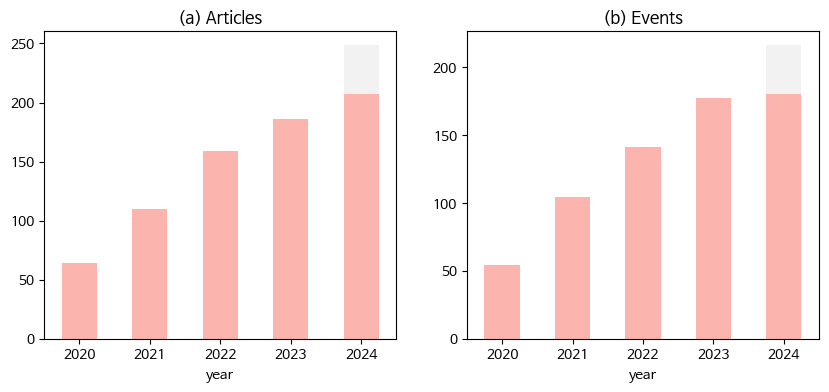

In [65]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

data = df_[['year']].reset_index(names="# of articles").groupby('year').count().reset_index()
data['estimated'] = 0
data.loc[data.year=='2024', 'estimated'] = data.loc[data.year=='2024', '# of articles']/5
data.plot(x='year', kind='bar', stacked=True, rot=0, title = '(a) Articles', legend=False, colormap='Pastel1', ax = axes[0])
# plt.show()

data = df_[['event_id','year']].drop_duplicates().groupby('year').count().rename(columns={'event_id':"# of events"})
data['estimated'] = 0
data.loc['2024', 'estimated'] = data.loc['2024', '# of events']/5
data= data.reset_index()
data.plot(x='year', kind='bar', stacked=True, rot=0, title = '(b) Events', legend=False, colormap='Pastel1', ax = axes[1])

# plt.show()

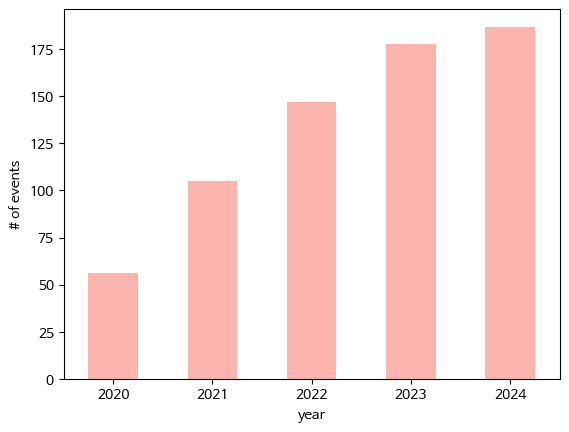

In [66]:
data = df_[['event_id', 'year', 'business']].drop_duplicates().groupby('year').count().rename(columns={'event_id':"# of events"})
data['business'] = ~data['business'].isna()
# data['estimated'] = 0
# data.loc['2024', 'estimated'] = data.loc['2024', '# of events']/5
data= data.reset_index()
fig, ax = plt.subplots()
data.plot(x='year', kind='bar', stacked=True, rot=0, ax = ax, ylabel = '# of events', legend=False, colormap='Pastel1')
plt.show()

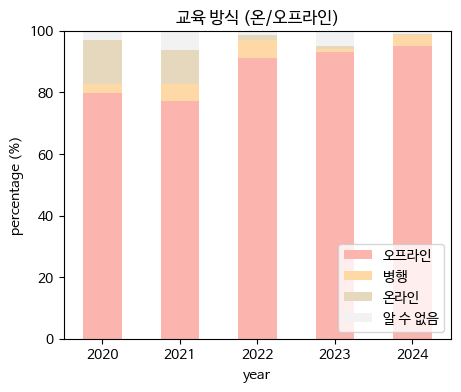

In [67]:
fig, ax = plt.subplots(figsize=(5,4))

data = df_[['year', '교육 방식']].copy()
data.loc[:,'온라인'] = data.loc[:,'교육 방식'].str.contains('온라인')
data.loc[:,'오프라인'] = data.loc[:,'교육 방식'].str.contains('오프라인')
data.loc[:,'병행'] = data.loc[:,'온라인'] & data.loc[:,'오프라인']
data.loc[:,'온라인'] = data.loc[:,'온라인'] & ~data.loc[:,'병행']
data.loc[:,'오프라인'] = data.loc[:,'오프라인'] & ~data.loc[:,'병행']
data.loc[:, 'annual_total'] = 1

data = data.drop(columns=['교육 방식']).groupby(['year']).sum()
data.loc[:, '알 수 없음'] = data.loc[:, 'annual_total'] - data[['온라인', '병행', '오프라인']].sum(axis=1)
data = (data[['오프라인', '병행', '온라인', '알 수 없음']].divide(data.loc[:, 'annual_total'], axis=0) * 100).reset_index()

cmap = colors.ListedColormap([plt.get_cmap('Pastel1').colors[0], plt.get_cmap('Pastel1').colors[4], plt.get_cmap('Pastel1').colors[6], plt.get_cmap('Pastel1').colors[8]])

data.plot(x='year', kind='bar', stacked=True, rot=0, title = '교육 방식 (온/오프라인)', colormap=cmap, ax = ax, ylabel = 'percentage (%)')
ax.set_ylim(0, 100)
ax.legend(loc='lower right')

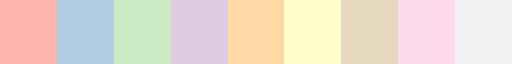

In [68]:
plt.get_cmap('Pastel1')

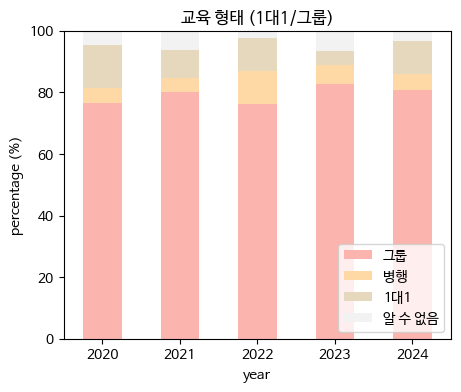

In [69]:
fig, ax = plt.subplots(figsize=(5,4))

data = df_[['year', '교육 형태']].copy()
data.loc[:,'1대1'] = data.loc[:,'교육 형태'].str.contains('1대1')
data.loc[:,'그룹'] = data.loc[:,'교육 형태'].str.contains('그룹')
data.loc[:,'병행'] = data.loc[:,'1대1'] & data.loc[:,'그룹']
data.loc[:,'1대1'] = data.loc[:,'1대1'] & ~data.loc[:,'병행']
data.loc[:,'그룹'] = data.loc[:,'그룹'] & ~data.loc[:,'병행']
data.loc[:, 'annual_total'] = 1

data = data.drop(columns=['교육 형태']).groupby(['year']).sum()
data.loc[:, '알 수 없음'] = data.loc[:, 'annual_total'] - data[['그룹', '병행', '1대1']].sum(axis=1)

data = (data[['그룹', '병행', '1대1', '알 수 없음']].divide(data.loc[:, 'annual_total'], axis=0) * 100).reset_index()
cmap = colors.ListedColormap([plt.get_cmap('Pastel1').colors[0], plt.get_cmap('Pastel1').colors[4], plt.get_cmap('Pastel1').colors[6], plt.get_cmap('Pastel1').colors[8]])
data.plot(x='year', kind='bar', stacked=True, rot=0, title = '교육 형태 (1대1/그룹)', colormap=cmap, ax = ax, ylabel = 'percentage (%)')
ax.set_ylim(0, 100)
ax.legend(loc='lower right')

### 키워드 트렌드

스마트폰, 키오스크

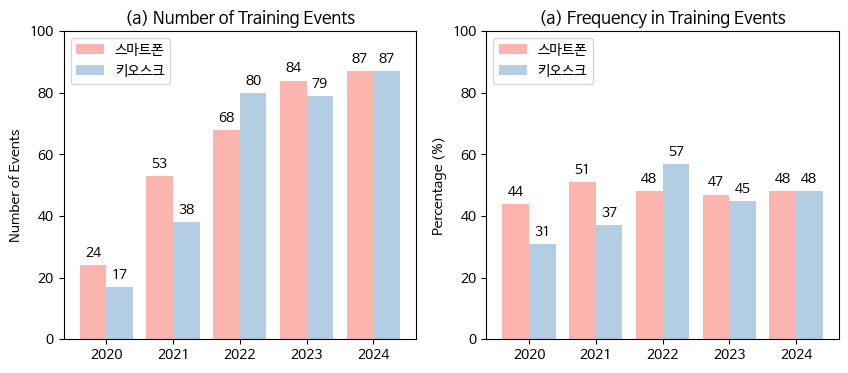

In [70]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
data = df_.copy()

data = data.groupby(['event_id', 'year'])[['내용']].agg(lambda l: ','.join(l))
data.loc[:,'스마트폰'] = data.loc[:,'내용'].str.contains('스마트폰')
data.loc[:,'키오스크'] = data.loc[:,'내용'].str.contains('키오스크')
data.loc[:,'events'] = 1

data = data.drop(columns=['내용']).groupby(['year']).sum()

x = np.arange(len(data))  # the label locations
width = 0.4  # the width of the bars

for data, ax, args in zip([data, data.divide(data['events'], axis=0).mul(100).round(0)], axes, [{'ylabel':'Number of Events', 'title':'(a) Number of Training Events', 'ylim':100}, {'ylabel':'Percentage (%)', 'title':'(a) Frequency in Training Events', 'ylim':100}]):
  multiplier = 0
  for column in ['스마트폰', '키오스크']:
    offset = width * multiplier
    rects = ax.bar(x + offset, data.loc[:, column], width, label=column, color=plt.get_cmap('Pastel1').colors[multiplier])
    ax.bar_label(rects, padding=3)
    multiplier += 1

  ax.set_ylabel(args['ylabel'])
  ax.set_title(args['title'])
  ax.set_xticks(x + width/2, data.index)
  ax.legend(loc='upper left')
  ax.set_ylim(0, args['ylim'])

튜터

In [71]:
!pip install konlpy
!pip install mecab-ko
!pip install mecab-dic
!pip install mecab-python
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

ERROR: Could not find a version that satisfies the requirement mecab-dic (from versions: none)
ERROR: No matching distribution found for mecab-dic
mecab-ko is already installed
mecab-ko-dic is already installed
mecab-python is already installed
Done.


In [72]:
!pip install wordcloud

In [73]:
from konlpy.tag import Mecab
mecab = Mecab()

In [74]:
import re
df_tutors = df_.copy().loc[df_.튜터 !=""].groupby(['event_id', 'year'])[['튜터']].agg(lambda l : ','.join(l))
print(len(df_tutors), len(df_))

df_tutors.튜터 = df_tutors.튜터.str.replace('전문 강사', '전문강사')

manually_identified_keywords = ['디지털배움터', '어디나지원단', '전문강사', '봉사', '서포터즈']
for manually_identified_keyword in manually_identified_keywords:
  df_tutors.loc[:, manually_identified_keyword] = df_tutors.튜터.str.contains(manually_identified_keyword)
  df_tutors.튜터 = df_tutors.튜터.str.replace(manually_identified_keyword, '')
df_tutors.loc[:, '튜터_tokens'] = df_tutors.튜터.map(lambda x : list(set(mecab.pos(re.sub('[^A-Za-z가-힣]', '' ,x)))))
df_tutors

248 726


튜터  디지털배움터  \
event_id year                                                              
10       2020                                            IT  29명   False   
101      2022                                          디지털 강사 및    False   
         2023                                         4명의 중년 강사단   False   
104      2024  호서대학교 대학생 42명,대학생 디지털  42명,나사렛대학교,공주대학교,한국기술교육...   False   
107      2024                  36명의 준고령층 강사 (시니어 강사 양성 교육과정 이수자)   False   
...                                                          ...     ...   
81       2022                                             시니어 강사   False   
83       2021                             그린빌즈(아주대학교 경제학과 학생 5명)   False   
84       2023                                              KT IT   False   
89       2021                                                      False   
92       2023                                            정보화 교육    False   

               어디나지원단   전문강사     봉사   서포터즈  \
event_id year                                
10       2020   False  False  False   True   
101      2022   False  False  False   True   
         2023   False  False  False  False   
104      2024   False  False  False   True   
107      2024   False  False  False  False   
...               ...    ...    ...    ...   
81       2022   False  False  False  False   
83       2021   False  False  False  False   
84       2023   False  False  False   True   
89       2021   False   True  False  False   
92       2023   False   True  False  False   

                                                       튜터_tokens  
event_id year                                                     
10       2020                               [(명, NNG), (IT, SL)]  
101      2022                  [(강사, NNG), (및, MAJ), (디지털, NNG)]  
         2023  [(강, NNG), (의, JKG), (명, NNG), (사단, NNG), (중년,...  
104      2024  [(명, NNG), (나사렛, NNG), (기술, NNG), (한국, NNP), (...  
107      2024  [(양성, NNG), (층, XSN), (의, JKG), (명, NNG), (이, ...  
...                                                          ...  
81       2022                            [(시니어, NNP), (강사, NNG)]  
83       2021  [(즈, XSN), (아주, MAG), (생명, NNG), (과학, NNG), (경...  
84       2023                                       [(KTIT, SL)]  
89       2021                                                 []  
92       2023                   [(화, XSN), (교육, NNG), (정보, NNG)]  

[248 rows x 7 columns]

In [75]:
from collections import Counter

document = [i for row in df_tutors.튜터_tokens.tolist() for i in row]
for token, count in df_tutors[manually_identified_keywords].sum(axis=0).items():
  document += [(token, 'NNG')]*count

counter = Counter(document)

df_temp = pd.Series([x[0] for x in counter.keys()]).value_counts()
stopwords = df_temp[df_temp > 1].index.tolist()
stopwords += ['교육']
counts = dict([(k[0], v) for (k,v) in counter.items() if k[0] not in stopwords and k[1][0] !="J" and k[1][0] !="X" and v > 2])

In [76]:
# worksheet = gc.open_by_url('https://docs.google.com/spreadsheets/d/1Q-I-uay6DnMalRUOQWQkI4-V9yeDNPZJVRuMpRkKi4U/edit?usp=sharing').worksheet('tutor_tokens')
# df_wordcloud = pd.DataFrame.from_dict(counts, orient="index", columns=["count"]).reset_index(names="token")
# worksheet.update([df.columns.values.tolist()] + df.fillna("").values.tolist()+[[""]*len(df.columns)])

In [77]:
worksheet = gc.open_by_url('https://docs.google.com/spreadsheets/d/1Q-I-uay6DnMalRUOQWQkI4-V9yeDNPZJVRuMpRkKi4U/edit?usp=sharing').worksheet('tutor_tokens')
rows = worksheet.get_all_values()
df_wordcloud = pd.DataFrame.from_records(rows[1:], columns=rows[0]).set_index('token')

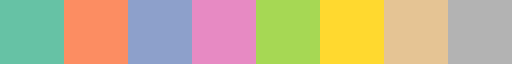

In [78]:
plt.get_cmap('Set2')

In [79]:
cdict = dict(zip(sorted(df_wordcloud['class'].unique().tolist(), key=len, reverse=True), list(reversed(plt.get_cmap('Set2').colors[:len(df_wordcloud['class'].unique())-1])) + list(plt.get_cmap('Set2').colors[-1:]) ))

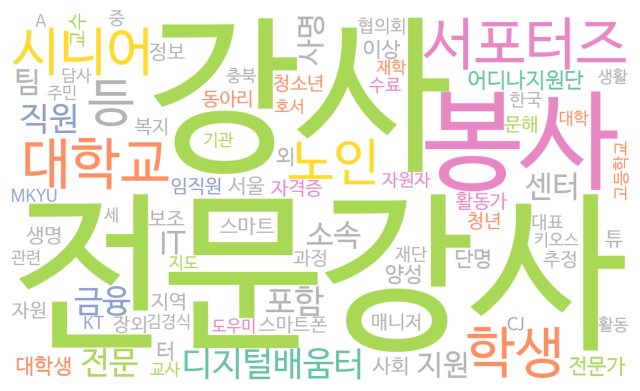

In [80]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import colorsys

def color_func(word, font_size, position,orientation,random_state=None, **kwargs):
  rgb = cdict[df_wordcloud.loc[word, 'class']]
  hsl = colorsys.rgb_to_hls(*rgb)
  return("hsl({:d},{:d}%, {:d}%)".format(int(round(hsl[0]*359)), int(round(hsl[2]*100)), int(round(hsl[1]*100))))

wc= WordCloud(
    width = 1000,
    height = 600,
    random_state=1,
    background_color='white',
    prefer_horizontal=0.95,
    collocations=False,
    stopwords = stopwords,
    font_path='./font/NanumBarunGothic.ttf',
    color_func=color_func,
    relative_scaling=0.3
    )

wc.generate_from_frequencies(counts)

plt.figure(figsize=(8, 6))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [81]:
print(df_wordcloud[df_wordcloud['class']=='student'].index.tolist())
print(df_wordcloud[df_wordcloud['class']=='older adult'].index.tolist())

['대학교', '학생', '대학생', '청년', '청소년', '동아리', '대학', '호서', '재학', '고등학교']
['시니어', '노인']


In [82]:
df_tutors['token'] = df_tutors.튜터_tokens.map(lambda l:[x[0] for x in l])

for key, token_list in [('노인', ['노인', '시니어', '중년']), ('1020', ['학생', '청소년', '청년', '대학', '대학교', '고등학교', '재학'])]:
  df_tutors[key] = False
  for token in token_list:
    df_tutors[key] = df_tutors[key] | df_tutors.token.apply(lambda l: token in l)

df_tutors.노인 = df_tutors.노인 | df_tutors.어디나지원단

In [83]:
df_tutors

튜터  디지털배움터  \
event_id year                                                              
10       2020                                            IT  29명   False   
101      2022                                          디지털 강사 및    False   
         2023                                         4명의 중년 강사단   False   
104      2024  호서대학교 대학생 42명,대학생 디지털  42명,나사렛대학교,공주대학교,한국기술교육...   False   
107      2024                  36명의 준고령층 강사 (시니어 강사 양성 교육과정 이수자)   False   
...                                                          ...     ...   
81       2022                                             시니어 강사   False   
83       2021                             그린빌즈(아주대학교 경제학과 학생 5명)   False   
84       2023                                              KT IT   False   
89       2021                                                      False   
92       2023                                            정보화 교육    False   

               어디나지원단   전문강사     봉사   서포터즈  \
event_id year                                
10       2020   False  False  False   True   
101      2022   False  False  False   True   
         2023   False  False  False  False   
104      2024   False  False  False   True   
107      2024   False  False  False  False   
...               ...    ...    ...    ...   
81       2022   False  False  False  False   
83       2021   False  False  False  False   
84       2023   False  False  False   True   
89       2021   False   True  False  False   
92       2023   False   True  False  False   

                                                       튜터_tokens  \
event_id year                                                      
10       2020                               [(명, NNG), (IT, SL)]   
101      2022                  [(강사, NNG), (및, MAJ), (디지털, NNG)]   
         2023  [(강, NNG), (의, JKG), (명, NNG), (사단, NNG), (중년,...   
104      2024  [(명, NNG), (나사렛, NNG), (기술, NNG), (한국, NNP), (...   
107      2024  [(양성, NNG), (층, XSN), (의, JKG), (명, NNG), (이, ...   
...                                                          ...   
81       2022                            [(시니어, NNP), (강사, NNG)]   
83       2021  [(즈, XSN), (아주, MAG), (생명, NNG), (과학, NNG), (경...   
84       2023                                       [(KTIT, SL)]   
89       2021                                                 []   
92       2023                   [(화, XSN), (교육, NNG), (정보, NNG)]   

                                                           token     노인   1020  
event_id year                                                                   
10       2020                                            [명, IT]  False  False  
101      2022                                       [강사, 및, 디지털]  False  False  
         2023                                  [강, 의, 명, 사단, 중년]   True  False  
104      2024  [명, 나사렛, 기술, 한국, 생명, 단국, 대학생, 디지털, 교육, 대학, 호서,...  False   True  
107      2024       [양성, 층, 의, 명, 이, 시니어, 고령, 교육, 준, 과정, 수자, 강사]   True  False  
...                                                          ...    ...    ...  
81       2022                                          [시니어, 강사]   True  False  
83       2021                     [즈, 아주, 생명, 과학, 경제학, 대학교, 그린빌]  False   True  
84       2023                                             [KTIT]  False  False  
89       2021                                                 []  False  False  
92       2023                                        [화, 교육, 정보]  False  False  

[248 rows x 10 columns]

(0.0, 16.0)

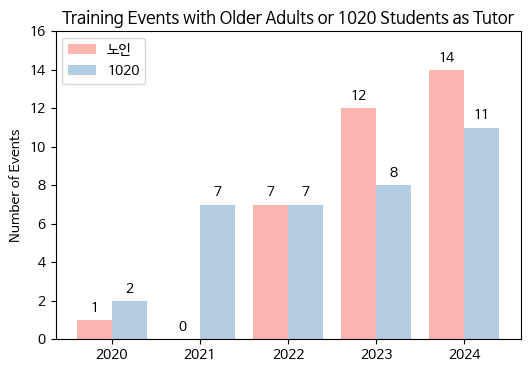

In [84]:
fig, ax = plt.subplots(figsize=(6,4))
data = df_tutors.copy()

keys = ['노인', '1020']

data = data.groupby(['year'])[keys].sum()
x = np.arange(len(data))  # the label locations
width = 0.4  # the width of the bars

multiplier = 0
for column in keys:
  offset = width * multiplier
  rects = ax.bar(x + offset, data.loc[:, column], width, label=column, color=plt.get_cmap('Pastel1').colors[multiplier])
  ax.bar_label(rects, padding=3)
  multiplier += 1
data
ax.set_ylabel('Number of Events')
ax.set_title('Training Events with Older Adults or 1020 Students as Tutor')
ax.set_xticks(x + width/2, data.index)
ax.legend(loc='upper left')
ax.set_ylim(0, 16)

In [85]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.0 MB/s eta 0:00:00


In [86]:
from bertopic import BERTopic

topic_model = BERTopic(language="multilingual")
topics, probs = topic_model.fit_transform(list(counts.keys()))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [87]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,79,-1_cj_스마트_충북_청소년,"[cj, 스마트, 충북, 청소년, 정보, 전문강사, 키오스, 포함, 학생, 한국]","[KT, 생명, 시니어]"


In [88]:
solid_style = {'color': 'gray', 'edgecolor': 'black', 'alpha': 0.65, 'linewidth': 0}

In [89]:
df_[['id', '연도', '연도', '연도']]

KeyError: "None of [Index(['id', '연도', '연도', '연도'], dtype='object')] are in the [columns]"

In [ ]:
df = df_data.copy()

In [ ]:
import re
df['tokens_목적'] = df.목적.map(lambda x: ','.join(['|'.join(list(s)) for s in mecab.pos(re.sub('[^A-Za-z0-9가-힣]', '' ,x))]))
df['tokens_내용'] = df.내용.map(lambda x: ','.join(['|'.join(list(s)) for s in mecab.pos(re.sub('[^A-Za-z0-9가-힣]', '' ,x))]))
df.to_csv("/content/drive/MyDrive/workspace/한국의 고령자 대상 디지털 교육훈련 사례 DB 구축/bigkinds news search/extended search/output/events.tsv", sep="\t")

In [ ]:
df.tokens_목적 = df.tokens_목적.map(lambda x: [s for s in x.split(',')])
df.tokens_내용 = df.tokens_내용.map(lambda x: [s for s in x.split(',')])
df

In [ ]:
df = df.groupby(['id', '연도'])[['tokens_목적', 'tokens_내용']].agg(lambda l: list(set([i for row in l for i in row if len(i)>0])))

In [ ]:
# https://www.kaggle.com/code/rowhitswami/keywords-extraction-using-tf-idf-method

def sort_coo(coo_matrix):
    """Sort a dict with highest score"""
    tuples = zip(coo_matrix.col, coo_matrix.data)
    return sorted(tuples, key=lambda x: (x[1], x[0]), reverse=True)

def extract_topn_from_vector(feature_names, sorted_items, topn=20):
    """get the feature names and tf-idf score of top n items"""

    #use only topn items from vector
    sorted_items = sorted_items[:topn]

    score_vals = []
    feature_vals = []

    # word index and corresponding tf-idf score
    for idx, score in sorted_items:

        #keep track of feature name and its corresponding score
        score_vals.append(round(score, 3))
        feature_vals.append(feature_names[idx])

    #create a tuples of feature, score
    results= {}
    for idx in range(len(feature_vals)):
        results[feature_vals[idx]]=score_vals[idx]

    return results

def get_keywords(vectorizer, feature_names, doc):
    """Return top k keywords from a doc using TF-IDF method"""
    TOP_K_KEYWORDS = 20

    #generate tf-idf for the given document
    tf_idf_vector = vectorizer.transform([doc])

    #sort the tf-idf vectors by descending order of scores
    sorted_items=sort_coo(tf_idf_vector.tocoo())

    #extract only TOP_K_KEYWORDS
    keywords=extract_topn_from_vector(feature_names,sorted_items,TOP_K_KEYWORDS)

    return list(keywords.keys())

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpora = df['tokens_내용'].groupby('연도').agg(lambda l : [i.split('|') for row in l for i in row if i.split('|')]).apply(lambda l : ' '.join([x[0] for x in l if x[1][0]=="N"])).tolist()

# Initializing TF-IDF Vectorizer with stopwords
vectorizer = TfidfVectorizer(use_idf=True, sublinear_tf=True, max_df=1.0)

# Creating vocab with our corpora
# Exlcluding first 10 docs for testing purpose
vectorizer.fit_transform(corpora)

# Storing vocab
feature_names = vectorizer.get_feature_names_out()

result = []
for doc in corpora:
    df_temp = {}
    df_temp['full_text'] = doc
    df_temp['top_keywords'] = get_keywords(vectorizer, feature_names, doc)
    result.append(df_temp)

final = pd.DataFrame(result)
print('\n'.join([','.join(x) for x in final.top_keywords.tolist()]))

In [ ]:
platform_to_synonyms={"pc": ["pc", "컴퓨터", "데스크탑", "모니터", "노트북"], "smartphone":["스마트폰", "모바일", "앱", "어플", "핸드폰", "휴대폰"], "tablet": ["태블릿", "아이패드"], "kiosk": ["kiosk", "키오스크", "키오스트", "키오"]}
platforms = list(platform_to_synonyms.keys())

In [ ]:

style={}

data = df_.copy()
data['키워드'] = data['키워드'].apply(lambda x: x.lower())
for (platform, synonyms) in platform_to_synonyms.items():
  data[platform] = False
  for synonym in synonyms:
     data[platform] = data[platform] | data['키워드'].str.contains(synonym)

data['articles'] = 1
data = data[['year','articles']+platforms].groupby('year').sum()
# data[platforms] = data[platforms].div(data["articles"], axis=0)
print(data.head())
# for platform in platforms:
sns.lineplot(data=data[platforms], **style)
plt.show()

In [ ]:
style = {'color': 'gray', 'alpha': 0.65, 'linewidth': 0}
style={}

data = df_.copy()
data['키워드'] = data['키워드'].apply(lambda x: x.lower())
for (platform, synonyms) in platform_to_synonyms.items():
  data[platform] = False
  for synonym in synonyms:
     data[platform] = data[platform] | data['키워드'].str.contains(synonym)

data = data[['year', 'event_id']+platforms].groupby(by=['year', 'event_id']).any()
data['events'] = 1
data = data.groupby('year').sum()

data[platforms] = data[platforms].div(data["events"], axis=0)
print(data.head())
# for platform in platforms:
sns.lineplot(data=data[platforms], **style)
plt.show()

In [ ]:
data = df_.copy()
keyword = '금융'
data['키워드'] = data['키워드'].apply(lambda x: x.lower())
data[keyword] =  data['키워드'].str.contains(keyword)
data['articles'] = 1
data_ = data[['year','articles', keyword]].groupby('year').sum()
data_[keyword] = data_[keyword].div(data_["articles"], axis=0)
print(data_.head())
# for platform in platforms:
sns.lineplot(data=data_[keyword], **style)
plt.show()

In [ ]:
data_ = data[['year', 'event_id', keyword]].groupby(by=['year', 'event_id']).any()
data_['events'] = 1
data_ = data_.groupby('year').sum()

data_[keyword] = data_[keyword].div(data_["events"], axis=0)
print(data_.head())
# for platform in platforms:
sns.lineplot(data=data_[keyword], **style)
plt.show()

### 지역

In [ ]:
raise NotImplementedError

In [ ]:
data = df_.copy()
data.지역 = data.지역.str.split(',')
data = data.explode('지역')
cities = ['서울특별시', '부산광역시', '대구광역시', '인천광역시', '광주광역시', '대전광역시', '울산광역시', '세종특별자치시', '경기도', '충청북도', '충청남도', '전라북도', '전라남도', '경상북도', '경상남도', '제주특별자치도', '강원특별자치도', "전북특별자치도"]
data['시'] = data['지역'].apply(lambda x: [city for city in cities if city in x])

data = data.explode('시')
data['시'] = data['시'].apply(lambda x: "전라북도" if x=="전북특별자치도" else x)
data = data.rename(columns={'시':'CTP_KOR_NM'})
data['events'] = 1
data['articles'] = data.articles.map(lambda x: len(x.split(',')))
data = data[['year', 'CTP_KOR_NM', 'event_id', 'articles', 'events']].set_index('CTP_KOR_NM', append=True)
data

In [ ]:
data['서울'] = data.index.get_level_values(1).isin(['서울특별시'])
data['수도권'] = data.index.get_level_values(1).isin(['경기도', '인천광역시'])
data['지방_광역시'] = data.index.get_level_values(1).isin(['부산광역시', '대구광역시', '대전광역시', '울산광역시', '광주광역시'])
data['지방'] = data.index.get_level_values(1).isin(['강원특별자치도', '충청북도', '충청남도', '전라북도', '전라남도', '경상북도', '경상남도', '제주특별자치도'])
data.head()
# data_ = data.groupby(['year'])

In [ ]:
data_ = data.copy()
data_ = data_.groupby('year').sum()
sns.lineplot(data=data_[['서울', '수도권', '지방_광역시', '지방']], **style)
plt.show()

In [ ]:
from matplotlib import colors
data_.head()
data_.reset_index()[['year', '서울', '수도권', '지방_광역시', '지방']].rename(columns={'서울':'Seoul (서울; Capital)', '수도권': 'Capital Region (수도권)', '지방_광역시': 'local metropolis (지방 광역시)', '지방': 'local (지방)'}).plot(x='year', kind='bar', stacked=True, rot=0, colormap=colors.ListedColormap(plt.get_cmap('Paired').colors[2:6]), ylabel='Events')

In [ ]:
import geopandas as gpd
path_korea_city_shp = "{}/data/ctprvn_20230729.zip".format(drive_root_path)

In [ ]:
cities = gpd.read_file(path_korea_city_shp, encoding="cp949")
print(cities.CTP_KOR_NM.unique().tolist())
cities.head()

In [ ]:
data_ = data.groupby('CTP_KOR_NM').sum()
data_ = cities.join(data_, on ="CTP_KOR_NM")
data_.plot(column='articles', cmap='OrRd')

In [ ]:
data_[data_['CTP_KOR_NM'] != "서울특별시"].plot(column='articles', cmap='OrRd')

In [ ]:
data_ = data.copy()
data_ = data_['events'].groupby('CTP_KOR_NM').sum()
data_ = cities.join(data_, on ="CTP_KOR_NM")
data_.plot(column='events', cmap='OrRd')

In [ ]:
data_[data_['CTP_KOR_NM'] != "서울특별시"].plot(column='events', cmap='OrRd')

In [ ]:
df_old_population = pd.read_csv("{}/202411_202411_주민등록인구기타현황(고령 인구현황)_OldAge.csv".format(dir_region), index_col=False, encoding='cp949')[['행정구역', '2024년11월_65세이상남자']]
df_old_population.columns=['CTP_KOR_NM', '202411_POP']
df_old_population['202411_POP'] = df_old_population['202411_POP'].apply(lambda x: x.replace(',','')).astype(int)
df_old_population['CTP_KOR_NM'] = df_old_population['CTP_KOR_NM'].apply(lambda x: str(x.split()[0]).strip())
df_old_population.loc[df_old_population['CTP_KOR_NM']=='전북특별자치도', 'CTP_KOR_NM'] = '전라북도'
df_old_population = df_old_population.set_index("CTP_KOR_NM", drop=True)
df_old_population.head(10)

cities = cities.join(df_old_population, on ="CTP_KOR_NM")
cities.head()

In [ ]:
data_ = data.groupby('CTP_KOR_NM').sum()
data_ = cities.join(data_, on ="CTP_KOR_NM")
data_['articles_per_population'] = data_['articles'].divide(data_['202411_POP'])
data_['events_per_population'] = data_['events'].divide(data_['202411_POP'])
for column in ['articles', 'events']:
  new_column = '{}_per_population'.format(column)
  data_[new_column] = data_[column].divide(data_['202411_POP'])
  data_[new_column] = data_[new_column] / data_[new_column].abs().max()

data_.head()
data = data_

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15,4))

data_ = data.copy()
data_.plot(column='articles', cmap='OrRd', ax=axes[0], legend=True, legend_kwds={'shrink': 0.5})

data_[data_['CTP_KOR_NM'] != "서울특별시"].plot(column='events', cmap='OrRd', ax=axes[1], legend=True, legend_kwds={'shrink': 0.5})

data_.plot(column='events_per_population', cmap='OrRd', ax=axes[2], legend=True, legend_kwds={'shrink': 0.5})

data_['articles_per_event'] = data_['articles'].div(data_['events'])
data_.plot(column='articles_per_event', cmap='OrRd', ax=axes[3], legend=True, legend_kwds={'shrink': 0.5})

axes[0].set_title("(a) Events", fontsize=10)
axes[1].set_title("(b) Events (Except Seoul)", fontsize=10)
axes[2].set_title("(c) Events Per Older Adult Population (Normalized)", fontsize=10)
axes[3].set_title("(d) Articles Per Event", fontsize=10)

for i in [0,1,2,3]:
  axes[i].set_xticklabels([])
  axes[i].set_yticklabels([])

fig.subplots_adjust(wspace=0.1)
plt.show()
# fig.update_annotations(font_size=9)

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,4))

data_ = data.copy()
data_.plot(column='articles', cmap='OrRd', ax=axes[0], legend=True, legend_kwds={'shrink': 0.5})

data_[data_['CTP_KOR_NM'] != "서울특별시"].plot(column='events', cmap='OrRd', ax=axes[1], legend=True, legend_kwds={'shrink': 0.5})

axes[0].set_title("(a) Events", fontsize=10)
axes[1].set_title("(b) Events (Except Seoul)", fontsize=10)

for i in [0,1]:
  axes[i].set_xticklabels([])
  axes[i].set_yticklabels([])

fig.subplots_adjust(wspace=0.1)
plt.show()
# fig.update_annotations(font_size=9)

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,4))

data_ = data.copy()

data_.plot(column='events_per_population', cmap='OrRd', ax=axes[0], legend=True, legend_kwds={'shrink': 0.5})

data_['articles_per_event'] = data_['articles'].div(data_['events'])
data_.plot(column='articles_per_event', cmap='OrRd', ax=axes[1], legend=True, legend_kwds={'shrink': 0.5})

axes[0].set_title("(c) Events Per Older Adult Population (Normalized)", fontsize=10)
axes[1].set_title("(d) Articles Per Event", fontsize=10)

for i in [0,1]:
  axes[i].set_xticklabels([])
  axes[i].set_yticklabels([])

fig.subplots_adjust(wspace=0.1)
plt.show()
# fig.update_annotations(font_size=9)

In [ ]:
data_.plot(column='articles_per_population', cmap='OrRd')

In [ ]:
data_.plot(column='events_per_population', cmap='OrRd')

In [ ]:
data_['articles_per_event'] = data_['articles'].div(data_['events'])
data_.plot(column='articles_per_event', cmap='OrRd')

### 기관 클러스터링

#### 전처리

지역명 제거

In [ ]:
import re

df_region = pd.read_csv("{}/data_region.tsv".format(dir_region), sep="\t", index_col="법정동코드")[["시", "군", "구", "동"]]
synonyms = pd.read_csv("{}/synonym_to_city_name.tsv".format(dir_region), sep="\t")["synonym"].unique().tolist()

regions = sorted(df_region.stack().unique().tolist() + synonyms, key=len, reverse=True)
print(regions)

In [ ]:
import re

df_org_vocab = pd.DataFrame(list(set([ i.strip() for row in df_data.기관.apply(lambda x: str(x).split(',')).to_list() for i in row if len(i)>0 ])), columns=["name"])
df_org_vocab["region_neutral_name"] = df_org_vocab["name"]
df_org_vocab["region_neutral_name"] = df_org_vocab["region_neutral_name"].apply(lambda x: x.split(' 등 ')[0].strip().split(' 및 ')[0].strip())
print([x for x in df_org_vocab["region_neutral_name"].unique().tolist() if len(x) < 5 and not x in regions])

지방 정부 이름 설정

In [ ]:
# 지역명 풀네임 제거 (e.g. 서울시, 충청북도, 서구, 가경동)
region_name_pattern = '|'.join(map(re.escape, regions))
df_org_vocab.loc[df_org_vocab.region_neutral_name.isin(["용현 1"]), "region_neutral_name"] = "local_government"
df_org_vocab.loc[df_org_vocab.region_neutral_name.isin(regions), "region_neutral_name"] = "local_government"
df_org_vocab["region_neutral_name"] = df_org_vocab["region_neutral_name"].apply(lambda x: re.sub(region_name_pattern, '', x)).apply(lambda x: x.strip())
df_org_vocab.loc[df_org_vocab.region_neutral_name.isin(['광역시', '구' '사무소', '도', '시', '군', '연산8동', '거제1동', "주민센터", "주민자치센터", '행정복지센터', '자치회관', '마을관리소']), "region_neutral_name"] = "local_government"
df_org_vocab.loc[df_org_vocab.region_neutral_name.isin(['']), "region_neutral_name"] = "local_government"
print([x for x in df_org_vocab.loc[df_org_vocab["name"] != df_org_vocab["region_neutral_name"], "region_neutral_name"].unique().tolist() if len(x) < 7])

In [ ]:
print(df_org_vocab[df_org_vocab['name'].apply(lambda x: '시설' in x)])
print(df_org_vocab[df_org_vocab['name'].apply(lambda x: '시니어' in x)])
print(df_org_vocab[df_org_vocab.region_neutral_name.apply(lambda x: '립' in x)])
df_org_vocab.loc[df_org_vocab['name'].apply(lambda x: '시설' in x), "region_neutral_name"] = df_org_vocab.loc[df_org_vocab['name'].apply(lambda x: '시설' in x), "region_neutral_name"].apply(lambda x: "시"+x)
df_org_vocab.loc[df_org_vocab['name'].apply(lambda x: '시니어' in x) & df_org_vocab.region_neutral_name.apply(lambda x: '시니어' not in x), "region_neutral_name"] = df_org_vocab.loc[df_org_vocab['name'].apply(lambda x: '시니어' in x) & df_org_vocab.region_neutral_name.apply(lambda x: '시니어' not in x), "region_neutral_name"].apply(lambda x: x.replace("니어", "시니어"))
df_org_vocab.loc[df_org_vocab.region_neutral_name.apply(lambda x: '립' in x), "region_neutral_name"] = df_org_vocab.loc[df_org_vocab.region_neutral_name.apply(lambda x: '립' in x), "region_neutral_name"].apply(lambda x: x.split("립")[1].strip())
print(df_org_vocab[df_org_vocab['name'].apply(lambda x: '시설' in x)])
print(df_org_vocab[df_org_vocab['name'].apply(lambda x: '시니어' in x)])
print(df_org_vocab[df_org_vocab.region_neutral_name.apply(lambda x: '립' in x)])

In [ ]:
raise NotImplementedError

제거할 지역명 Prefix: 2글자 이상의 prefix, [서포, 예산, 고령, 삼성] 제외

In [ ]:
synonym_to_regions = pd.read_csv(path_synonym_to_regions, sep="\t", index_col="key").value.to_dict()
cities = df_region[['시', '군', '구', '동']].stack().unique().tolist() +['전라북도']
city_prefixes = [ x for x in synonym_to_regions.keys() if str(synonym_to_regions[x]).split(',')[0] in cities and x not in ["서포", "예산", "고령", "삼성", "문화", "행정"] ] + list(set(synonym_to_regions.values())) + synonyms
city_prefixes = list(set(city_prefixes))

In [ ]:
for i in range(5):
  for n in [5, 4, 3, 2]:
    for i in range(2):
      df_org_vocab["region_neutral_name"] = df_org_vocab["region_neutral_name"].apply(lambda x: x[n:] if (x[:n] in city_prefixes) else x ).apply(lambda x: x.strip())
      df_org_vocab.loc[df_org_vocab["region_neutral_name"].apply(lambda x: "대" in x.split(' ') or "여대" in x.split(' ')), "region_neutral_name"] = "대학교"

df_org_vocab.region_neutral_name = df_org_vocab.region_neutral_name.apply(lambda x: x[:-2] if str(x).endswith("지회") else x)
print(df_org_vocab[df_org_vocab['region_neutral_name'] != df_org_vocab['name']][df_org_vocab['region_neutral_name'] != "local_government"].head(30))

In [ ]:
print(df_org_vocab[df_org_vocab.region_neutral_name.apply(lambda x: len(str(x)) < 3)].region_neutral_name.unique().tolist())

In [ ]:
raise NotImplementedError

학과 및 분과 처리

In [ ]:
print([x for x in df_org_vocab.region_neutral_name.unique() if x[-1:] == "과" ])

In [ ]:
df_org_vocab.loc[df_org_vocab.region_neutral_name.apply(lambda x: x[-2:] == "학과"), "region_neutral_name"] = "college_department"
df_org_vocab.loc[df_org_vocab.region_neutral_name.apply(lambda x: x[-1:] == "과"), "region_neutral_name"] = "local_government"

"한국" 처리

In [ ]:
df_org_vocab.region_neutral_name = df_org_vocab.region_neutral_name.apply(lambda x: re.sub("한국", '', x))

In [ ]:
df_org_vocab.region_neutral_name = df_org_vocab.region_neutral_name.apply(lambda x: x if len(x) > 1 else "" )

In [ ]:
df_org_vocab[df_org_vocab.region_neutral_name.apply(lambda x: str(x)[-1:] == "시")]

In [ ]:
df_org_vocab.loc[df_org_vocab.region_neutral_name.str.contains("도서관"), "region_neutral_name"] = "도서관"

저장

In [ ]:
df_org_vocab.to_csv(path_org_to_region_stripped, sep="\t", index=False)
df_org_vocab.head()

In [ ]:
raise NotImplementedError

#### 클러스터링

데이터 - 기관명 Vocabulary

In [ ]:
df_org_vocab = pd.read_csv(path_org_to_region_stripped, sep="\t", index_col=False, dtype=str)
df_org_vocab.head()

In [ ]:
import re

vocab_name = "region_neutral_organization_name"
max_length = 8
codes = ['local_government', 'college_department']

vocab = df_org_vocab.region_neutral_name
vocab = vocab[vocab.notnull()].tolist()
vocab = list(set([str(x).strip() for x in vocab]))
vocab = [x for x in vocab if (x not in codes) and len(x) > 1]
documents = list(set(vocab))
print(len(vocab))
print([x for x in vocab if re.compile('[a-z]').match(x)])

Modeling

In [ ]:
raise NotImplementedError

In [ ]:
from transformers import AutoModel, AutoTokenizer
import torch
from torch.utils.data import DataLoader
import random
from tqdm import tqdm

model_name_to_id = {
  # paraphrase-multilingual-mpnet
  "paraphrase-multilingual-mpnet":"sentence-transformers/paraphrase-multilingual-mpnet-base-v2",

  # Kobert
  "kobert":"monologg/kobert",

  # Kpf-bert
  'kpf-bert':'leewaay/kpf-bert-base-klueNLI-klueSTS-MSL512',
}

def encode_bert(documents, model_name, dir_name, gpu=True):
  model_id = model_name_to_id[model_name]
  # gpu = True
  # gpu = False
  device = torch.device("cuda:0")
  tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True, device_map = 'cuda' if gpu else None)
  model = AutoModel.from_pretrained(model_id, device_map = 'cuda' if gpu else None).to(device)

  batch_size = 16

  dataloader = DataLoader(documents, batch_size=16, shuffle=False)
  embeddings = []

  for index, batch in enumerate(tqdm(dataloader)):
      inputs = tokenizer.__call__(batch, padding='max_length', max_length=max_length, return_tensors="pt", truncation=True ).to(device)
      out = model(input_ids = torch.tensor(inputs['input_ids']), attention_mask = torch.tensor(inputs['attention_mask']))
      embeddings.append(out.pooler_output.detach().cpu().numpy())

  df_dataset = pd.DataFrame(columns=["embedding", "token"])
  df_dataset["embedding"] = [ i for row in  embeddings for i in row ]
  df_dataset["token"] = documents
  df_dataset.head()

  df_dataset.to_pickle("{}/{}/{}/{}/embeddings.pkl".format(dir_embedding, model_name, dir_name))

  return df_dataset

SentenceTransformer (paraphrase-multilingual-mpnet, kpf-bert)

In [ ]:
# paraphrase-multilingual-mpnet
# model_id="sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
# model_name="paraphrase-multilingual-mpnet"

# Kobert
# model_id="monologg/kobert"
# model_name="kobert"

# Kpf-bert
model_id='leewaay/kpf-bert-base-klueNLI-klueSTS-MSL512'
model_name='kpf-bert'

dir_model = "{}/{}".format(dir_embedding, model_name)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True, device_map = 'cuda' if gpu else None)
model = AutoModel.from_pretrained(model_id, device_map = 'cuda' if gpu else None).to(device)

In [ ]:
from torch.utils.data import DataLoader
from tqdm import tqdm

# max_length = 256
batch_size = 16

dataloader = DataLoader(documents, batch_size=16, shuffle=False)
embeddings = []

for index, batch in enumerate(tqdm(dataloader)):

    inputs = tokenizer.__call__(batch, padding='max_length', max_length=max_length, return_tensors="pt", truncation=True ).to(device)
    out = model(input_ids = torch.tensor(inputs['input_ids']),
                attention_mask = torch.tensor(inputs['attention_mask']))
    embeddings.append(out.pooler_output.detach().cpu().numpy())

In [ ]:
print(len([ i for row in  embeddings for i in row ]))
print(len(documents))

In [ ]:
df_dataset = pd.DataFrame(columns=["embedding", "token"])
df_dataset["embedding"] = [ i for row in  embeddings for i in row ]
df_dataset["token"] = documents
df_dataset.head()

In [ ]:
df_dataset.to_pickle("{}/{}/embeddings.pkl".format(dir_model, vocab_name))

BERTOPIC

In [ ]:
raise NotImplementedError

In [ ]:
!pip install bertopic

In [ ]:
import pickle

df_dataset = pd.read_pickle("{}/{}/embeddings.pkl".format(dir_model, vocab_name))
df_dataset.head()

embeddings = np.array(df_dataset.embedding.tolist())
documents = df_dataset.token.tolist()

In [ ]:
from umap import UMAP
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)

In [ ]:
from bertopic import BERTopic
from hdbscan import HDBSCAN

# hdbscan_model = HDBSCAN(
#     min_cluster_size=8
# )

min_topic_size = 3

topic_model = BERTopic(
    embedding_model=model_id,
    # hdbscan_model=hdbscan_model,
    min_topic_size=min_topic_size
)

In [ ]:
# topic_model = BERTopic.load("{}/{}/bertopic".format(dir_model, vocab_name), embedding_model=model_id)

In [ ]:
topics, probs = topic_model.fit_transform([x.replace('[SEP]', '') for x in documents], embeddings)

topic_model.save("{}/{}/min_topic_size-{}/bertopic".format(dir_model, vocab_name, min_topic_size), serialization="safetensors", save_ctfidf=True, save_embedding_model=model_id)
print(topic_model.get_topic_info())
topic_model.visualize_documents(documents, reduced_embeddings=reduced_embeddings)

In [ ]:
df_topic = topic_model.get_document_info(documents)[['Document', 'Topic', "Name"]].sort_values(by="Topic", ascending=True)
# df_topic['class'] = df_topic['Topic'].apply(lambda x: topic_to_class[x])

In [ ]:
topic_to_class={
    -1: '', 0: 'welfare center', 1: 'government (welfare)', 2: 'lifelong education', 3: 'college', 4: 'government (IT & Digitization)', 5:'senior group', 6: 'education', 7: 'local community', 8: 'public enterprise', 9:'local government',
    10:'government (IT & Digitization)', 11: 'senior group', 12:'civic group', 13:'government (media)', 14:"", 15:'public enterprise', 16: '', 17: 'education', 18: 'government (IT & Digitization)'}

In [ ]:
df_topic['class'] = df_topic.Topic.map(lambda x: topic_to_class[x])

In [ ]:
path_df_vocab_topics = "{}/{}/min_topic_size-{}/document_topics.tsv".format(dir_model, vocab_name, min_topic_size)
df_topic.to_csv(path_df_vocab_topics, sep="\t", index=False)
df_topic.head(1)

worksheet = gc.open_by_url('https://docs.google.com/spreadsheets/d/1Q-I-uay6DnMalRUOQWQkI4-V9yeDNPZJVRuMpRkKi4U/edit?gid=1241755608#gid=1241755608').worksheet('organization_clusters')
worksheet.update([df_topic.columns.values.tolist()] + df_topic.fillna("").values.tolist()+[[""]*len(df_topic.columns)])

In [ ]:
raise KeyboardInterrupt

### 기관 및 기업 분류

In [ ]:
raise NotImplementedError

In [ ]:
# sns.reset_defaults()
# %matplotlib inline

In [ ]:
from pandas.api.types import CategoricalDtype

worksheet = gc.open_by_url('https://docs.google.com/spreadsheets/d/1Q-I-uay6DnMalRUOQWQkI4-V9yeDNPZJVRuMpRkKi4U/edit?gid=1241755608#gid=1241755608').worksheet('organization_clusters')
rows = worksheet.get_all_values()
df_topic = pd.DataFrame.from_records(rows[1:], columns=rows[0]).set_index('Document')
df_topic.org_class = df_topic.org_class.apply(lambda x: 'etc' if x=='' else x)
df_topic.head()

min_topic_size = 3
vocab_name = "region_neutral_organization_name"

# Kpf-bert
model_id='leewaay/kpf-bert-base-klueNLI-klueSTS-MSL512'
model_name='kpf-bert'
dir_model = "{}/{}".format(dir_embedding, model_name)

df_dataset = pd.read_pickle("{}/{}/embeddings.pkl".format(dir_model, vocab_name))
df_dataset.head()

embeddings = np.array(df_dataset.embedding.tolist())
documents = df_dataset.token.tolist()

In [ ]:
# import pickle
# from sklearn.manifold import TSNE

# X = embeddings

# # We want to get TSNE embedding with 2 dimensions
# n_components = 2
# tsne = TSNE(n_components)
# tsne_result = tsne.fit_transform(X)
# tsne_result.shape

# with open("{}/{}/tsne_result.pkl".format(dir_model, vocab_name), "wb") as fOut:
#     pickle.dump(tsne_result, fOut)

In [ ]:
import pickle

with open("{}/{}/tsne_result.pkl".format(dir_model, vocab_name), "rb") as f:
    tsne_result = pickle.load(f)

In [ ]:
df_org_vocab = pd.read_csv(path_org_to_region_stripped, dtype=str, sep="\t").set_index('name')[['region_neutral_name']]

df_org_to_class = df_org_vocab.rename(columns={'region_neutral_name':'Document'}).join(df_topic[['org_class']], on ="Document")
df_org_to_class.loc[df_org_to_class.Document == "local_government", "org_class"] = "local government"
df_org_to_class.loc[df_org_to_class.Document == "college_department", "org_class"] = "college"
df_org_to_class = df_org_to_class.drop(columns=["Document"])
df_cluster = df_topic.copy()

df = df_data[['id', '연도', '기관', '기업']].copy()
df.기관 = df.기관.apply(lambda x: str(x).split(','))
df.기업 = df.기업.apply(lambda x: str(x).split(','))

print(len(df))
df = df.groupby(['id', '연도']).agg(lambda x: list(set([i for row in x for i in row])))
print(len(df))

df.기관 = df.기관.apply(lambda n: [df_org_to_class.loc[x, 'org_class'] for x in n if len(x)>0])

for classname in (df_topic.org_class.unique().tolist() + ['local government']):
  df[classname] = df.기관.apply(lambda x: classname in x)

df['business'] = df.기업.apply(lambda x: len(x) > 1)

org_class_counts = df.drop(columns=['기관','기업']).sum(axis=0).to_frame().rename(columns={0:'count'}).rename_axis('org_class').sort_values(by="count", ascending=False)
org_class_counts['count'] = org_class_counts['count'].astype(int)
org_class_sorter = [x for x in org_class_counts.index.tolist() if x != 'etc']
print(org_class_sorter)

In [ ]:
df_org_to_class.to_csv("{}/{}/min_topic_size-{}/org_to_class.tsv".format(dir_model, vocab_name, min_topic_size), sep="\t", index_label="name")

In [ ]:
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
top_n = 8

xlim = (tsne_result.min()+8, tsne_result.max()-5)
ylim = (tsne_result.min()+3, tsne_result.max()+2)

ax=axes[0]

tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:,0], 'tsne_2': tsne_result[:,1], 'org_class': df_topic.loc[documents, 'org_class']})

show = [x for x in org_class_sorter[:top_n+2] if x not in ['local government', 'business']]
# show = [x for x in  if x not in ['local government', 'business']]
tsne_result_df['hue'] = tsne_result_df.org_class.apply(lambda x: x if x in show else "etc")
tsne_result_df['hue'] = tsne_result_df['hue'].astype(CategoricalDtype(categories=show+["etc"], ordered=True))

sns.scatterplot(x='tsne_1', y='tsne_2', alpha=0.2, data=tsne_result_df[~tsne_result_df.org_class.apply(lambda x: x in show)], ax=ax, color="gray", size=2, legend=False)
sns.scatterplot(x='tsne_1', y='tsne_2', hue='hue', data=tsne_result_df[tsne_result_df.org_class.apply(lambda x: x in show)], alpha=0.7, ax=ax, palette=sns.color_palette("muted"), legend=False)
lim = (tsne_result.min()-10, tsne_result.max()+10)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set(xlabel='tsne-x', ylabel='tsne-y')
ax.set_aspect('equal')

cluster_df = tsne_result_df[['tsne_1',	'tsne_2',	'org_class']].groupby('org_class').mean()
cluster_df.loc['local government'] = [-22, 5]
cluster_df.loc['business'] = [-22, -11]
cluster_df = cluster_df.join(org_class_counts)
cluster_df = cluster_df.loc[cluster_df.index != "etc"].sort_values(by="count", ascending=False)

cluster_df['size'] = cluster_df['count'].pow(2)

for i, point in cluster_df.iloc[:top_n+2].iterrows():
  if(point.name in ['local government', 'business']):
    continue
  ax.text(point.tsne_1-(0 if '(welfare)' in point.name else 5), point.tsne_2+(5 if '(older adults)' in point.name else 0) , '\n'.join(
      [point.name.split(' ')[0]] \
      + ([' '.join(point.name.split(' ')[1:])] if len(point.name.split(' ')) > 1 else []) \
      ))

ax = axes[1]

cp = []
j = 0
for i in cluster_df.index.tolist()[:top_n+2]:
  if(i in ['local government', 'business']):
    cp.append("gray")
  else:
    cp.append(sns.color_palette("muted")[j])
    j += 1

sns.scatterplot(x='tsne_1', y='tsne_2', hue='org_class', size="size", sizes=(200, 10000), data=cluster_df, ax=ax, alpha=0.5, palette = cp+["gray"]*10, legend=False)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set(xlabel='tsne-x', ylabel='tsne-y')
ax.set_aspect('equal')

ax.add_patch(Rectangle((-36, -16), 28, 34, fill=False))

for i, point in cluster_df.iloc[:top_n+2].iterrows():
    ax.text(point.tsne_1-(0 if '(welfare)' in point.name else 5), point.tsne_2 , '\n'.join(
        [point.name.split(' ')[0]] \
        + ([' '.join(point.name.split(' ')[1:])] if len(point.name.split(' ')) > 1 else []) \
        ))


axes[0].set_title("(a) Sentence-BERT embedding of organization names", fontsize=10)
axes[1].set_title("(b) Number of paritcipations in training events", fontsize=10)
fig.tight_layout()

# h, l = ax.get_legend_handles_labels()
# ax.legend(h[2:6]+h[7:top_n+3], l[2:6]+l[7:top_n+3], bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
# ax.set(xlabel='tsne-x', ylabel='tsne-y')

In [ ]:
df_org_to_class = pd.read_csv("{}/{}/min_topic_size-{}/org_to_class.tsv".format(dir_model, vocab_name, min_topic_size), sep="\t", dtype=str).set_index('name')

df_cluster = df_topic.copy()

df = df_data[['id', '연도', '기관', '기업']].copy()
df.기관 = df.기관.str.replace('경인여자대학교 간호학과 NURSING  AI 동아리', '경인여대 간호학과 NURSING  AI 동아리')
df.기관 = df.기관.apply(lambda x: str(x).split(','))
df.기업 = df.기업.apply(lambda x: str(x).split(','))

print(len(df))
df = df.groupby(['id', '연도']).agg(lambda x: list(set([i for row in x for i in row])))
print(len(df))

business_counts = pd.DataFrame([ i for row in df.기업.tolist() for i in row if len(i)>0]).value_counts().to_frame().reset_index(names="name")
business_counts['org_class'] = 'business'

org_counts = pd.DataFrame([ i for row in df.기관.tolist() for i in row if len(i)>0 ]).value_counts().to_frame().reset_index(names=['name'])

org_counts['org_class'] = org_counts['name'].apply(lambda x: df_org_to_class.loc[x])

org_counts = pd.concat([business_counts, org_counts]).sort_values(by="count", ascending=False).reset_index(drop=True)
org_counts.to_csv("{}/organization_nodes.tsv".format(dir_output), sep="\t", index_label="id")
org_counts.name = org_counts.name.apply(lambda x: '\n'.join([x[:int(len(x)/2)], x[int(len(x)/2):]]) if len(x)>10 else x)

In [ ]:
from  matplotlib.ticker import FuncFormatter

org_counts_ = org_counts.copy()
org_class_list = org_counts_.org_class.unique().tolist()
# org_counts_.org_class = org_counts_.org_class.apply(lambda x: cluster_to_ordered_cluster[x] if x > 0 else x)
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16,10))
fig.subplots_adjust(hspace=0.4, wspace=0.8)
j = 0

cluster_df['count'] = cluster_df['count'].astype(int)

for i, ax in enumerate(axes.flatten()):
  # title = ''
  # while(title == ''):
    # title = cluster_titles[j]
    # j+=1
  df = org_counts_[org_counts_.org_class == org_class_sorter[i]]
  sns.barplot(x="count", y="name", data=df.iloc[:5], **solid_style, ax=ax).set(xlabel=None, ylabel=None, title="{} ({})".format(org_class_sorter[i], cluster_df.loc[org_class_sorter[i], 'count']))
  ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x)))

In [ ]:
for j in range(3):
  fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(18,3))
  fig.subplots_adjust(hspace=0.4, wspace=0.6)

  cluster_df['count'] = cluster_df['count'].astype(int)

  for i, ax in enumerate(axes.flatten()):
    i = 4*j+i
    df = org_counts_[org_counts_.org_class == org_class_sorter[i]]
    sns.barplot(x="count", y="name", data=df.iloc[:5], **solid_style, ax=ax).set(xlabel=None, ylabel=None, title="{} ({})".format(org_class_sorter[i], cluster_df.loc[org_class_sorter[i], 'count']))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x)))

### 기관 및 기업 관계 분석 (Network Analysis)

In [ ]:
df_org_to_class = pd.read_csv("{}/{}/min_topic_size-{}/org_to_class.tsv".format(dir_model, vocab_name, min_topic_size), sep="\t", dtype=str, index_col=False).set_index('name')

df = df_data[['기관', '기업']].copy()
df.기관 = df.기관.apply(lambda x: [df_org_to_class.loc[n, 'org_class'] for n in str(x).split(',') if len(n)>0 ])

for classname in org_class_sorter:
  # print(classname)
  df[classname] = df.기관.apply(lambda x: classname in x)

In [ ]:
df_nodes = pd.read_csv("{}/organization_nodes.tsv".format(dir_output), sep="\t").set_index("id")
df_nodes.head()

In [ ]:
name_to_id = df_nodes.reset_index(names='id').set_index('name')['id'].to_dict()

In [ ]:
df = df_data[['id', '연도', '기관', '기업']].copy()
df.기관 = df.기관.apply(lambda x: str(x).split(','))
df.기업 = df.기업.apply(lambda x: str(x).split(','))
df['organization'] = (df.기관 + df.기업).apply(lambda l: [name_to_id[x] for x in l if x !=""])
df = df.groupby(['id', '연도'])['organization'].agg(lambda x: list(set([i for row in x for i in row])))

In [ ]:
df_edges = df[df.apply(lambda x: len(x) > 1)].to_frame()
df_edges['edges'] = df_edges.organization.apply(lambda l: [ i for row in [[[x, y] for y in l if x > y] for x in l] for i in row])
df_edges = df_edges.explode('edges')
df_edges['source'] = df_edges.edges.apply(lambda l: l[0])
df_edges['target'] = df_edges.edges.apply(lambda l: l[1])
df_edges = df_edges.drop(columns=['edges', 'organization']).reset_index().astype(int)
df_edges = df_edges.rename(columns={'id':'event_id'})
df_edges['weight'] = 1

In [ ]:
df_edges

In [ ]:
df_edges.reset_index().groupby(['id', '연도', 'source', 'target']).count().rename(columns={'index':'count'})['count']

In [ ]:
node_attribute_dict = df_nodes.to_dict(orient="index")

In [ ]:
import networkx as nx

G = nx.from_pandas_edgelist(df_edges, edge_attr=['weight', 'event_id', '연도'], create_using=nx.MultiGraph())
# G.add_nodes_from(df_nodes.index.tolist())
nx.set_node_attributes(G, node_attribute_dict)
nx.write_gexf(G, "{}/network.gexf".format(dir_output))

In [ ]:
df_nodes_with_edges = df_nodes.reset_index(names='id')
print(df_nodes_with_edges[df_nodes_with_edges.id.isin(G.nodes)][['id', 'org_class']].groupby('org_class').agg(lambda l: set(l))['id'].tolist())

In [ ]:
print(len(communities))
print(communities)

In [ ]:
net = Network(notebook=True, cdn_resources='in_line')
net.repulsion()
net.add_nodes(
    [int(x) for x in np.arange(len(org_class_order))], \
    value=[int(x) for x in org_class_counts.sort_values(by='count', ascending=False)['count'].tolist()], \
    label=org_class_order
)

df_edges = pd.DataFrame(columns=['x', 'y', 'weight'])

for i_, i in enumerate(org_class_order):
  for j_, j in enumerate(org_class_order):
    if(i_ > j_):
      df_edges.loc[len(df_edges)] = [i_, j_, int(df[[i, j]].all(axis=1).sum())]

In [ ]:
import plotly.express as px
fig = px.histogram(df_edges, x="weight")
fig.show()

In [ ]:
df_edges_ = df_edges[df_edges.weight > 10]

for i, row in df_edges_.iterrows():
  net.add_edge(int(row.x), int(row.y), weight=int(row.weight))

net.save_graph("simple_graph.html")

In [ ]:
from IPython.display import HTML
HTML(filename="simple_graph.html")